# **Library importation**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import missingno as mso
import cvxpy as cp
import statsmodels.api as sm
from pandas_datareader import data as pdr
from scipy.linalg import sqrtm
from sklearn.covariance import LedoitWolf

**Data reading and Data cleaning**

In [ ]:

# 1. Data reading
filepath = "/carteras-2026_prod_long_sharpe_u60_20260422_v1_train_dataset.xlsx"

data_raw = pd.read_excel(filepath)

print("Datos cargados:")
data_raw.head()

Datos cargados:


,1,2,3,4,5,6,7,8,9,10,...,51,52,53,54,55,56,57,58,59,60
0,-0.028988,0.000000,0.011857,-0.052465,-0.044951,-0.001556,-0.061189,-0.022658,-0.070095,-0.078670,...,-0.011112,-0.060292,-0.001453,-0.032199,-0.037156,0.000000,-0.032860,-0.050789,-0.038136,-0.019340
1,-0.001839,-0.009662,0.036648,0.002373,0.028330,0.060441,0.010914,0.042820,0.067410,-0.006427,...,0.008345,0.015417,0.000000,0.046082,-0.022330,0.025879,0.032860,-0.010135,-0.020619,0.053082
2,0.034392,0.013261,0.005665,0.030049,0.090729,0.010211,0.082024,0.020742,0.043399,0.013692,...,0.024625,-0.019566,0.059256,0.000000,0.074569,0.012694,-0.005092,0.043195,0.010854,0.050405
3,0.010620,0.022500,0.013097,0.072178,-0.003407,0.028614,-0.026600,0.055147,0.109022,0.136664,...,0.042334,0.008534,-0.006873,-0.024188,0.038184,0.007181,-0.007412,0.017728,0.072845,-0.002939
4,-0.007067,0.024293,-0.003725,-0.017852,-0.040040,-0.014205,-0.035274,-0.038666,0.098296,-0.011009,...,0.010310,0.014065,0.023178,0.010305,-0.005781,0.008904,-0.005327,-0.032470,-0.018416,-0.014080


In [ ]:
# Asset information for later use
filepath = "/carteras-2026_prod_long_sharpe_u60_20260422_v1_train_dataset.xlsx"
meta_df = pd.read_excel(filepath, sheet_name='Hoja2', index_col='Ticker')

In [ ]:
meta_df.head()

,PRICE_TO_BOOK,CAPITALIZACIÓN,SECTOR
Ticker,,,
1,13.141889,3.577200e+10,Healthcare Equipment & Supplies
2,24.578829,NaN,Software & IT Services
3,4.949696,NaN,Electric Utilities & IPPs
4,0.092198,3.121500e+12,Insurance
5,0.663867,NaN,Oil & Gas


<Axes: >

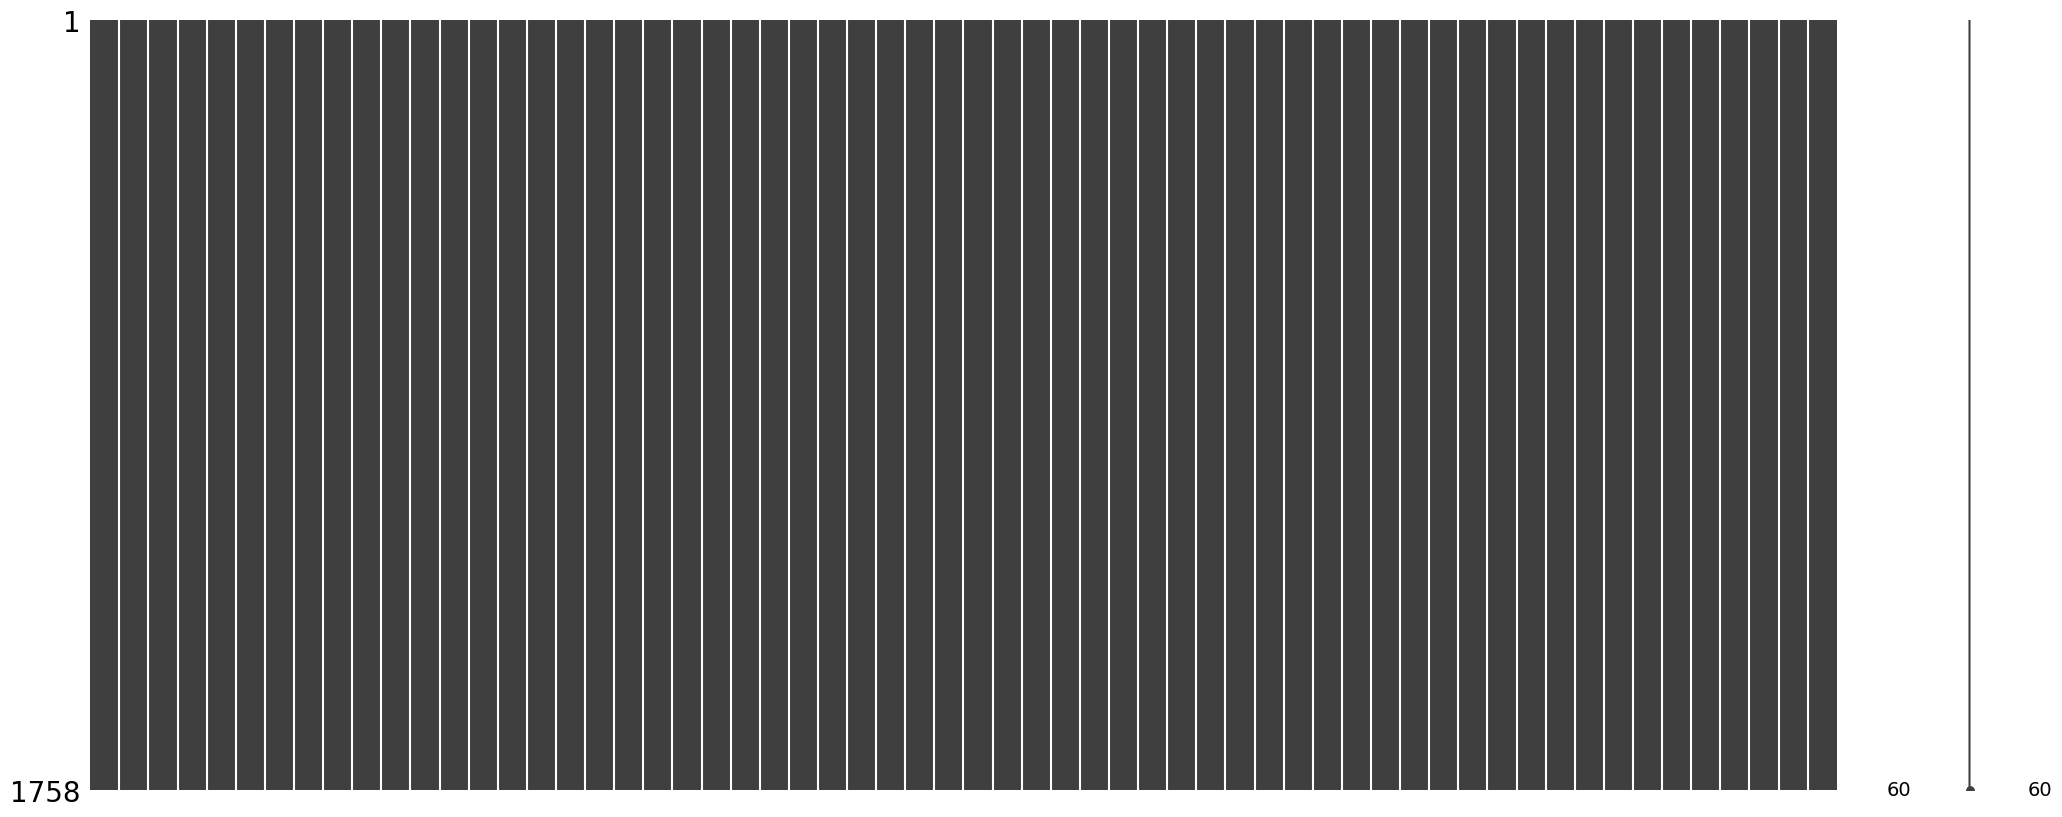

In [ ]:
# We use missingno library to check for missing values
mso.matrix(data_raw)

# **Exploratory Data Analysis**

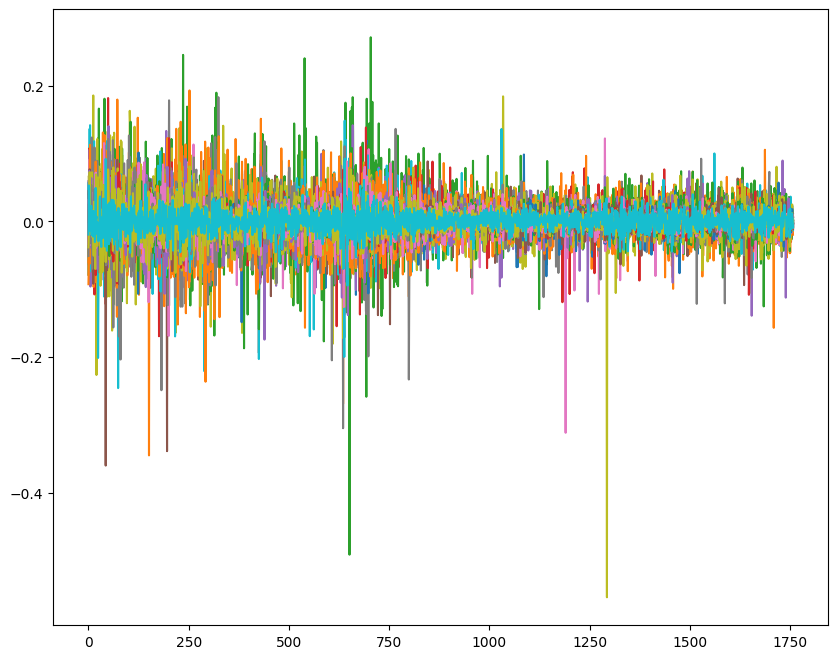

In [ ]:
# We can see diary returns

plt.figure(figsize=(10, 8))
plt.plot(data_raw)

In [ ]:
# We were given a Rf asset whose performance was 2%, annualized

rf_ano = 0.02
rf_dia = rf_ano / 252
rf_dia

7.936507936507937e-05

In [ ]:
data_raw['Rf'] = rf_dia
data_raw

,1,2,3,4,5,6,7,8,9,10,...,52,53,54,55,56,57,58,59,60,Rf
0,-0.028988,0.000000,0.011857,-0.052465,-0.044951,-0.001556,-0.061189,-0.022658,-0.070095,-0.078670,...,-0.060292,-0.001453,-0.032199,-0.037156,0.000000,-0.032860,-0.050789,-0.038136,-0.019340,0.000079
1,-0.001839,-0.009662,0.036648,0.002373,0.028330,0.060441,0.010914,0.042820,0.067410,-0.006427,...,0.015417,0.000000,0.046082,-0.022330,0.025879,0.032860,-0.010135,-0.020619,0.053082,0.000079
2,0.034392,0.013261,0.005665,0.030049,0.090729,0.010211,0.082024,0.020742,0.043399,0.013692,...,-0.019566,0.059256,0.000000,0.074569,0.012694,-0.005092,0.043195,0.010854,0.050405,0.000079
3,0.010620,0.022500,0.013097,0.072178,-0.003407,0.028614,-0.026600,0.055147,0.109022,0.136664,...,0.008534,-0.006873,-0.024188,0.038184,0.007181,-0.007412,0.017728,0.072845,-0.002939,0.000079
4,-0.007067,0.024293,-0.003725,-0.017852,-0.040040,-0.014205,-0.035274,-0.038666,0.098296,-0.011009,...,0.014065,0.023178,0.010305,-0.005781,0.008904,-0.005327,-0.032470,-0.018416,-0.014080,0.000079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1753,-0.005641,-0.006913,-0.003753,-0.003899,-0.006130,-0.013206,-0.002994,-0.007329,-0.012767,-0.001921,...,-0.005417,-0.006490,-0.009163,0.006021,-0.011026,-0.003551,-0.001395,-0.003726,-0.006082,0.000079
1754,0.010421,0.006913,0.008657,0.004732,-0.005866,0.000338,0.006539,0.002809,-0.001224,0.002305,...,0.000858,0.007915,0.004727,0.001091,0.000750,0.005457,0.002787,0.012439,0.008451,0.000079
1755,0.015840,-0.000203,-0.000234,0.003881,-0.000603,0.001013,0.001303,0.008807,0.003872,0.008787,...,0.011642,0.004588,0.012053,0.002478,0.002330,0.010557,0.003056,0.001084,0.011895,0.000079
1756,-0.001430,-0.001825,-0.005607,-0.005687,0.007219,0.001349,-0.002235,-0.002784,0.003655,0.000760,...,0.002256,0.002721,-0.002132,-0.001926,0.004146,0.004835,-0.003612,-0.003255,0.004797,0.000079


In [ ]:
def estimar_cov_robusta(data):
  ''' Function to estimate covariance matrix with robust estimator '''
    # LedoitWolfd covariance shrinkages outliers
  lw = LedoitWolf().fit(data)
  return lw.covariance_

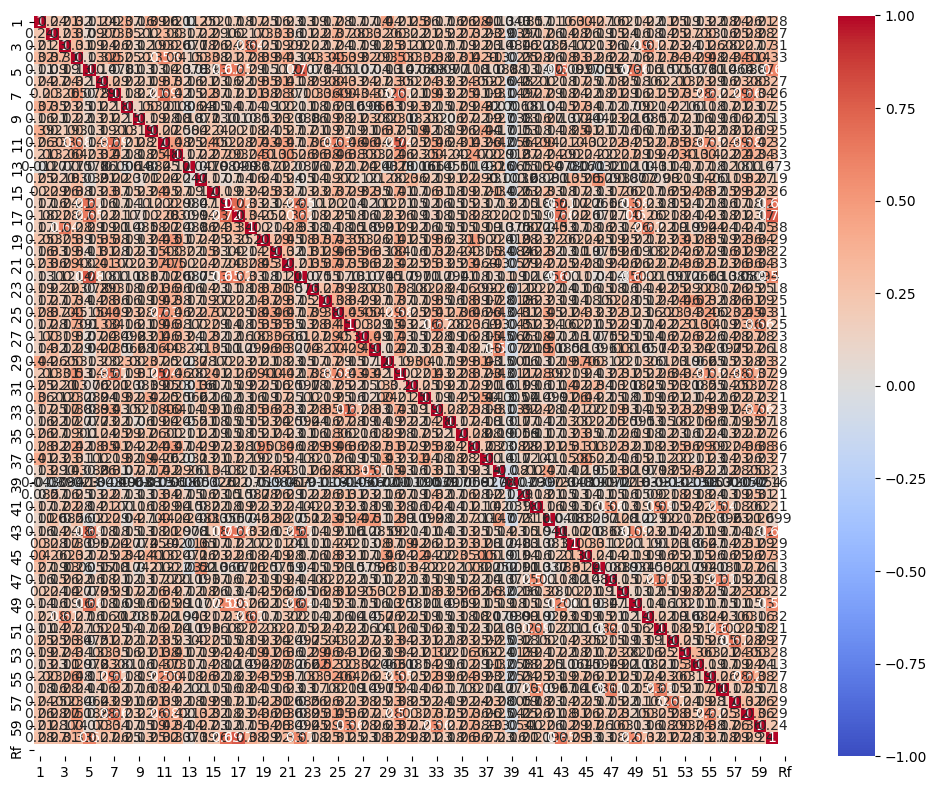

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data_raw.corr(), annot=True, cmap='coolwarm', vmin = -1, vmax = 1)
plt.tight_layout()

In [ ]:
ret = data_raw
ret.head()

,1,2,3,4,5,6,7,8,9,10,...,52,53,54,55,56,57,58,59,60,Rf
0,-0.028988,0.000000,0.011857,-0.052465,-0.044951,-0.001556,-0.061189,-0.022658,-0.070095,-0.078670,...,-0.060292,-0.001453,-0.032199,-0.037156,0.000000,-0.032860,-0.050789,-0.038136,-0.019340,0.000079
1,-0.001839,-0.009662,0.036648,0.002373,0.028330,0.060441,0.010914,0.042820,0.067410,-0.006427,...,0.015417,0.000000,0.046082,-0.022330,0.025879,0.032860,-0.010135,-0.020619,0.053082,0.000079
2,0.034392,0.013261,0.005665,0.030049,0.090729,0.010211,0.082024,0.020742,0.043399,0.013692,...,-0.019566,0.059256,0.000000,0.074569,0.012694,-0.005092,0.043195,0.010854,0.050405,0.000079
3,0.010620,0.022500,0.013097,0.072178,-0.003407,0.028614,-0.026600,0.055147,0.109022,0.136664,...,0.008534,-0.006873,-0.024188,0.038184,0.007181,-0.007412,0.017728,0.072845,-0.002939,0.000079
4,-0.007067,0.024293,-0.003725,-0.017852,-0.040040,-0.014205,-0.035274,-0.038666,0.098296,-0.011009,...,0.014065,0.023178,0.010305,-0.005781,0.008904,-0.005327,-0.032470,-0.018416,-0.014080,0.000079


# **Strategy development**

In [ ]:
# First: Minimum CVaR
def cartera_min_cvar(ret, alpha=0.05, max_peso = 0.1, max_rf = 0.1):
    """
    Minimiza la pérdida esperada en el peor alpha% de los casos.
    Incluye restricción específica para el activo 'RF_CASH'.
    """
    n = ret.shape[1]
    t = ret.shape[0]

    # Decision variables
    w = cp.Variable(n)

    # VaR (Value at Risk)
    gamma = cp.Variable()

    # u represents loss excess above VaR el
    u = cp.Variable(t)

    # Identify the Rf asset
    nombres_activos = list(ret.columns)
    idx_rf = nombres_activos.index('Rf') if 'Rf' in nombres_activos else None

    # Diary losses
    losses = -ret.values @ w

    # We define constraints
    constraints = [
        cp.sum(w) == 1,
        w <= max_peso,
        w >= 0,
        u >= 0,
        u >= losses - gamma
    ]

    # New condition for Rf
    if idx_rf is not None:
        constraints.append(w[idx_rf] <= max_rf)

    cvar = gamma + (1.0 / (t * alpha)) * cp.sum(u)

    prob = cp.Problem(cp.Minimize(cvar), constraints) # Minimize CVaR

    try:
        prob.solve()

        if w.value is None:
             return np.ones(n) / n

        pesos = w.value
        pesos_ajustados = np.where(pesos > 1e-4, pesos, 0)
        return pesos_ajustados / np.sum(pesos_ajustados)

    except Exception as e:
        print(f"Error en CVaR, usando 1/N: {e}")
        return np.ones(n) / n

In [ ]:
# Second: RP + RISK-ADJUSTED MOMENTUM
def cartera_risk_parity_sharpe(ret_df, top_n=40, rf_col_name='Rf'):
    """
    Risk Parity optimizado mediante SOCP con restricción de peso máximo para RF.
    Filtro inicial: Mejores activos según su Ratio de Sharpe individual.
    """
    # 1. We filter the best individual Sharpe

    retornos_medios = ret_df.mean()
    volatilidades = ret_df.std().replace(0, np.nan)

    sharpe_individual = retornos_medios / volatilidades

    # Select as many as we consider that are enough
    ganadores = sharpe_individual.nlargest(top_n).index
    ret_ganadores = ret_df[ganadores]

    num_act = ret_ganadores.shape[1]
    matriz_cov = estimar_cov_robusta(ret_ganadores)

    try:
        L = np.linalg.cholesky(matriz_cov)
    except np.linalg.LinAlgError:
        matriz_cov_segura = matriz_cov + np.eye(num_act) * 1e-8
        L = np.linalg.cholesky(matriz_cov_segura)

    b = 1 / num_act
    x = cp.Variable(num_act)
    gamma = cp.Variable(num_act, nonneg=True)
    psi = cp.Variable(nonneg=True)
    z = matriz_cov @ x

    # Objetive
    obj = cp.pnorm(b**0.5 * psi - gamma, p=2)

   # Constraints
    constraints = [
        cp.sum(x) == 1,
        x >= 0,
        cp.SOC(psi, L.T @ x)
    ]

    # Rf limit
    if rf_col_name in ganadores:
        idx_rf = list(ganadores).index(rf_col_name)
        constraints.append(x[idx_rf] <= 0.1) # Maximum 10%

    for i in range(num_act):
        constraints += [cp.SOC(x[i] + z[i], cp.vstack([2 * gamma[i], x[i] - z[i]]))]

    objective = cp.Minimize(obj * 1000)
    prob = cp.Problem(objective, constraints)

    try:
        prob.solve()
        if x.value is None:
            raise ValueError("El solver no convergió.")

        pesos = np.array([np.round(xi, 6) if xi > 10**-5 else 0 for xi in x.value])

    except Exception as e:
        print(f"  [Aviso] Risk Parity falló. Usando equiponderada. Motivo: {e}")
        pesos = np.ones(num_act) / num_act

    pesos /= np.sum(pesos)

    pesos_finales = pd.Series(0.0, index=ret_df.columns)
    pesos_finales[ganadores] = pesos
    return pesos_finales.values

In [ ]:
# THIRD: MINIMUM VOLATILITY

def cartera_min_vol(ret, max_peso=0.1):
    """Función que calcula la cartera de mínima varianza para un DataFrame de rendimientos
    ret: DataFrame de rendimientos
    Retorna pesos_ajustados: Array con los pesos de la cartera de mínima varianza"""

    if isinstance(ret, pd.DataFrame):
        lookback = min(126, len(ret))
        ret_recientes = ret.tail(lookback)

        num_act = ret_recientes.shape[1]
        matriz_cov = estimar_cov_robusta(ret_recientes)

        pesos = cp.Variable(num_act)
        riesgo = cp.quad_form(pesos, matriz_cov)

        # Constraints
        constraints = [
            pesos >= 0,
            cp.sum(pesos) == 1,
            pesos <= max_peso
        ]

        objective = cp.Minimize(riesgo)
        prob = cp.Problem(objective, constraints)


        try:
            prob.solve(solver=cp.OSQP)
            if pesos.value is None:
                raise ValueError("El solver no encontró solución.")
            pesos_crudos = pesos.value

        except Exception as e:
            print(f"  [Aviso] Min Vol falló. Usando equiponderada. Motivo: {e}")
            pesos_crudos = np.ones(num_act) / num_act

        pesos_limpios = np.array(
            [np.round(x, 3) if x > 10**-4 else 0 for x in pesos_crudos]
        )
        pesos_ajustados = pesos_limpios / np.sum(pesos_limpios)

        return pesos_ajustados

    else:
        raise ValueError(
            "La función cartera_min_vol solo acepta un DataFrame como argumento"
        )

In [ ]:
# FOURTH: EQUALLY WEIGHTED FOR THE LEAST RISKY ASSETS

def blend_less_risk(ret_df, min_pct=0.20, max_pct=0.60, rf_col_name='Rf'):
    """
    Estrategia de Búnker Dinámico.
    Busca el "salto natural" de volatilidad para decidir dónde cortar,
    evitando dejar fuera activos que son prácticamente igual de seguros.
    """
    # 1. Look at the past to adapt the potential crash
    lookback = min(24*21, len(ret_df))
    ret_recientes = ret_df.tail(lookback)

    volatilidades = ret_recientes.std().sort_values()
    num_total = len(volatilidades)

    # 2. Define the assets we are gonna get. Netiher 2 nor 60
    idx_min = max(3, int(num_total * min_pct))
    idx_max = int(num_total * max_pct)

    # 3. Difference in volatility between one asset and the previous one
    zona_busqueda = volatilidades.iloc[idx_min : idx_max]
    saltos = zona_busqueda.diff()

    if saltos.empty or saltos.isna().all():
        corte_final = idx_min
    else:
        # Avoid including the asset which gives more differential volatility
        activo_del_salto = saltos.idxmax()
        # Identify such asset
        corte_final = volatilidades.index.get_loc(activo_del_salto)

    # 4. We get all those assets before the 'jump'
    activos_refugio = volatilidades.iloc[:corte_final].index.tolist()

    pesos = pd.Series(0.0, index=ret_df.columns)

    if rf_col_name in ret_df.columns:
        pesos[rf_col_name] = 0.10  # Rf
        if rf_col_name in activos_refugio:
            activos_refugio.remove(rf_col_name)

        if len(activos_refugio) > 0:
            peso_resto = 0.90 / len(activos_refugio)
            pesos[activos_refugio] = peso_resto
    else:
        pesos[activos_refugio] = 1.0 / len(activos_refugio)

    return pesos.values

In [ ]:
# FIFTH: RP + BLENDING FOR SECURE INDUSTRIES

def optimum_rp_blending(ret_df, meta_df, rf_col_name='Rf'):
    """
    Essential for bear markets.
    Combination of secure industries + RP + Blending.
    """
    # Secure assets
    sectores_seguros = [
        'Electric Utilities & IPPs', 'Pharmaceuticals',
        'Telecommunications Services', 'Beverages',
        'Consumer Goods Conglomerates', 'Healthcare Equipment & Supplies',
        'Food & Drug Retailing'
    ]
    # Secure asset identification
    tickers_refugio = meta_df[meta_df['SECTOR'].isin(sectores_seguros)].index.astype(str)
    cols_comunes = [col for col in ret_df.columns if str(col) in tickers_refugio]

    # We get information to adapt to the crash
    lookback = min(63, len(ret_df))
    ret_recientes = ret_df[cols_comunes].tail(lookback)

    # We get the 50% least volatile assets
    volatilidades = ret_recientes.std().sort_values()
    num_seguros = max(5, int(len(volatilidades) * 0.5)) # 5 assets at least
    super_refugios = volatilidades.head(num_seguros).index.tolist()

    ret_final = ret_recientes[super_refugios]
    num_act = len(super_refugios)

    try:
        lw = LedoitWolf().fit(ret_final)
        matriz_cov = lw.covariance_

        pesos_a = cp.Variable(num_act)
        riesgo = cp.quad_form(pesos_a, matriz_cov)


        constraints = [
            pesos_a >= 0,
            cp.sum(pesos_a) == 1,
            pesos_a <= 0.15 # We try to diversify moderately
        ]

        prob = cp.Problem(cp.Minimize(riesgo), constraints)
        prob.solve(solver=cp.OSQP)

        if pesos_a.value is None:
            raise ValueError("Solver no convergió")

        w_min_vol = np.array([x if x > 1e-4 else 0 for x in pesos_a.value])
        w_min_vol /= np.sum(w_min_vol)

    except Exception as e:
        print(f"  [Aviso] Min Vol falló en Ensamblaje. Usando 1/N. Motivo: {e}")
        w_min_vol = np.ones(num_act) / num_act

    # Blending
    w_1_n = np.ones(num_act) / num_act

    # Combination
    pesos_mezcla = (0.50 * w_min_vol) + (0.50 * w_1_n)

    # Final weights
    pesos_finales = pd.Series(0.0, index=ret_df.columns)

    if rf_col_name in ret_df.columns:
        pesos_finales[rf_col_name] = 0.10
        pesos_finales[super_refugios] = pesos_mezcla * 0.90
    else:
        pesos_finales[super_refugios] = pesos_mezcla

    return pesos_finales.values

In [ ]:
def validar_estrategia(retornos, funcion_estrategia, nombre, lookback = 12):
    corte = int(len(retornos) * 0.7)
    train_completo, val = retornos.iloc[:corte], retornos.iloc[corte:]

    dias_atras = lookback * 21
    if len(train_completo) > dias_atras:
      train = train_completo[-dias_atras:]
    else:
      train = train_completo

    #try:
    w = funcion_estrategia(train)
    ret_train = train @ w
    ret_val = val @ w

    if ret_val.std() == 0:
      sharpe_val = 0
    elif ret_train.std() == 0:
      sharpe_train = 0
    else:
      sharpe_train = (ret_train.mean() / ret_train.std()) * np.sqrt(252)
      sharpe_val = (ret_val.mean() / ret_val.std()) * np.sqrt(252)
    print(f"ESTRATEGIA {nombre} -> Sharpe Train: {sharpe_train:.4f} / Sharpe Validación: {sharpe_val:.4f}")
    return ret_val, w
    #except:
        #print(f"Error en {nombre}")
        #return None, None

In [ ]:
pesos_intento_5 = optimum_rp_blending(ret, meta_df)

In [ ]:
ret.columns = ret.columns.astype(str)


res1, w1 = validar_estrategia(ret, cartera_min_cvar, "Mín CVaR")
res2, w2 = validar_estrategia(ret, cartera_risk_parity_sharpe, "Cartera Risk Parity")
res3, w3 = validar_estrategia(ret, cartera_min_vol, "Mínima Volatilidad")
res4, w4 = validar_estrategia(ret, blend_less_risk, "Equiponderada activos estables")



ESTRATEGIA Mín CVaR -> Sharpe Train: 1.7872 / Sharpe Validación: 1.3844
ESTRATEGIA Cartera Risk Parity -> Sharpe Train: 2.6827 / Sharpe Validación: 1.3064
ESTRATEGIA Mínima Volatilidad -> Sharpe Train: 1.9211 / Sharpe Validación: 1.2720
ESTRATEGIA Equiponderada activos estables -> Sharpe Train: 1.7800 / Sharpe Validación: 1.1126


In [ ]:
# Guardamos los resultados en un diccionario para iterar
resultados_pesos = {
    "Mín CVaR": w1,
    "Cartera Risk Parity": w2,
    "Mínima Volatilidad": w3,
    "Equiponderada activos estables": w4,
    "50/50 segura": pesos_intento_5
}

for nombre, pesos in resultados_pesos.items():
    print(f"\n" + "="*40)
    print(f" ESTRATEGIA: {nombre}")
    print("="*40)


    series_pesos = pd.Series(pesos, index=ret.columns)

    pesos_activos = series_pesos[series_pesos > 0.0001].sort_values(ascending=False)

    if not pesos_activos.empty:
        print(pesos_activos.round(3))
        print("-" * 20)
        print(f"Suma total: {pesos_activos.sum():.3f} | Activos seleccionados: {len(pesos_activos)}")
    else:
        print("Error: Esta estrategia no devolvió pesos válidos.")


 ESTRATEGIA: Mín CVaR
Rf    0.100
18    0.100
44    0.100
50    0.100
53    0.100
29    0.100
38    0.088
35    0.074
8     0.061
7     0.053
34    0.038
46    0.029
56    0.015
3     0.014
51    0.014
59    0.010
20    0.003
dtype: float64
--------------------
Suma total: 1.000 | Activos seleccionados: 17

 ESTRATEGIA: Cartera Risk Parity
Rf    0.100
29    0.073
50    0.063
18    0.036
46    0.030
34    0.027
38    0.026
58    0.026
54    0.026
7     0.025
2     0.024
57    0.024
8     0.023
52    0.023
40    0.023
3     0.023
56    0.022
55    0.021
60    0.021
17    0.020
25    0.020
30    0.019
51    0.019
26    0.019
41    0.019
6     0.019
24    0.018
16    0.018
21    0.018
48    0.018
49    0.017
47    0.017
20    0.017
22    0.017
43    0.017
5     0.016
12    0.015
19    0.015
13    0.015
9     0.014
dtype: float64
--------------------
Suma total: 1.000 | Activos seleccionados: 40

 ESTRATEGIA: Mínima Volatilidad
18    0.100
Rf    0.100
50    0.100
29    0.091
34    0.077
27

# Strategies we were avoiding at all

We were seeing that all our strategies provided fair results in any case. Nevertheless, the first time we submitted weights we saw every Sharpe ratio was below zero. The dataset we were working with had to do with a crisis.


---


It is proved that the Maximum Sharpe strategy tends to be glorious in bull markets, but a disaster in bear markets. However, I want you to see how did we prepare our Maximum Sharpe strategy function.





In [ ]:
# INTENTO 4: Cartera Max Sharpe
def cartera_max_sharpe(ret, ret_rf=0.0, max_peso=0.1):
    if isinstance(ret, pd.DataFrame):
        num_act = ret.shape[1]
        matriz_cov = estimar_cov_robusta(ret) # Usa tu cov robusta aquí también, es vital
        retornos_esperados = ret.mean().values

        x = cp.Variable(num_act)
        riesgo = cp.quad_form(x, matriz_cov)
        pi = retornos_esperados - ret_rf

        # Protección: Si todos los retornos esperados son negativos,
        # Max Sharpe no tiene sentido. Devolvemos equiponderada.
        if np.max(pi) <= 0:
            print("  [Aviso] Retornos esperados negativos. Usando 1/N.")
            return np.ones(num_act) / num_act

        constraints = [
            pi @ x == 1,
            x >= 0,
            x <= max_peso * cp.sum(x)
        ]

        objective = cp.Minimize(riesgo)
        problema = cp.Problem(objective, constraints)

        try:
            problema.solve()
            if x.value is None: # Si el solver no converge
                return np.ones(num_act) / num_act

            pesos = x.value
            pesos /= pesos.sum() # Normalizamos a 1
            pesos_ajustados = np.where(pesos > 1e-4, pesos, 0)
            return pesos_ajustados / np.sum(pesos_ajustados) # Volver a sumar 1 tras limpiar

        except Exception as e:
            return np.ones(num_act) / num_act
    else:
        raise ValueError("Requiere DataFrame")

In [ ]:
# INTENTO TRES: CARTERA RP + FACTOR MOMENTUM
def cartera_risk_parity(ret_df, top_n=30):
    """
    Risk Parity optimizado mediante SOCP (Conos de Segundo Orden).
    """
    # 1. Filtro Momentum
    ret_acum = (1 + ret_df).prod() - 1
    ganadores = ret_acum.nlargest(top_n).index
    ret_ganadores = ret_df[ganadores]

    num_act = ret_ganadores.shape[1]
    matriz_cov = estimar_cov_robusta(ret_ganadores) # Tu función Ledoit-Wolf

    # SOLUCIÓN 2: Usar Cholesky en lugar de sqrtm para evitar números complejos.
    # Si la matriz es definida positiva, L @ L.T = matriz_cov
    try:
        L = np.linalg.cholesky(matriz_cov)
    except np.linalg.LinAlgError:
        # Mecanismo de    matriz_cov_segura = matriz_cov + np.eye(num_act) * 1e-8
        L = np.linalg.cholesky(matriz_cov)

    b = 1 / num_act

    # Variables de decisión
    x = cp.Variable(num_act)
    gamma = cp.Variable(num_act, nonneg=True)
    psi = cp.Variable(nonneg=True)

    z = matriz_cov @ x

    # Objetivo
    obj = cp.pnorm(b**0.5 * psi - gamma, p=2)

    # SOLUCIÓN 1: Eliminada la línea 'ret = ...' que sobreescribía el DataFrame

    # Restricciones usando Cholesky (L.T @ x equivale a sqrtm)
    constraints = [
        cp.sum(x) == 1,
        x >= 0,
        cp.SOC(psi, L.T @ x)
    ]

    for i in range(num_act):
        constraints += [cp.SOC(x[i] + z[i], cp.vstack([2 * gamma[i], x[i] - z[i]]))]

    objective = cp.Minimize(obj * 1000)
    prob = cp.Problem(objective, constraints)

    # SOLUCIÓN 3: Control de fallos del solver
    try:
        prob.solve() # ECOS es ideal para problemas SOCP
        if x.value is None:
            raise ValueError("El solver no convergió.")

        pesos = np.array([np.round(xi, 3) if xi > 10**-4 else 0 for xi in x.value])

    except Exception as e:
        print(f"  [Aviso] Risk Parity falló. Usando equiponderada. Motivo: {e}")
        pesos = np.ones(num_act) / num_act

    # Volvemos a normalizar a 1 por si el redondeo ha quitado decimales
    pesos /= np.sum(pesos)

    # Reconstrucción de la serie final (ahora ret_df.columns funciona perfectamente)
    pesos_finales = pd.Series(0.0, index=ret_df.columns)
    pesos_finales[ganadores] = pesos
    return pesos_finales.values